In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../data/cleaned_data/merged_machine_data.csv')

In [8]:
df.head()

,Source,Air_Temperature,Process_Temp,Rotational_Speed,Torque,Life_Consumed,Stress_Index,RUL,Is_Failure,Health_Status
0,AI4I,299.228419,306.899157,1559.219588,43.187703,0,0.470538,50,0,Warning
1,AI4I,296.759079,307.729191,1405.990381,46.889688,3,0.505412,49,0,Warning
2,AI4I,298.018549,309.175868,1509.324445,49.237010,5,0.512735,48,0,Warning
3,AI4I,299.183173,308.553352,1425.993973,39.545599,7,0.478745,47,0,Warning
4,AI4I,300.709087,308.954130,1400.229355,40.097456,9,0.485819,46,0,Warning


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30631 entries, 0 to 30630
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Source            30631 non-null  object 
 1   Air_Temperature   30631 non-null  float64
 2   Process_Temp      30631 non-null  float64
 3   Rotational_Speed  30631 non-null  float64
 4   Torque            30631 non-null  float64
 5   Life_Consumed     30631 non-null  int64  
 6   Stress_Index      30631 non-null  float64
 7   RUL               30631 non-null  int64  
 8   Is_Failure        30631 non-null  int64  
 9   Health_Status     30631 non-null  object 
dtypes: float64(5), int64(3), object(2)
memory usage: 2.3+ MB


In [4]:
df.describe()

,Air_Temperature,Process_Temp,Rotational_Speed,Torque,Life_Consumed,Stress_Index,RUL,Is_Failure
count,30631.000000,30631.000000,30631.000000,30631.000000,30631.000000,30631.000000,30631.000000,30631.000000
mean,530.797567,1172.566555,2110.787236,45.074197,108.528125,0.829461,84.829944,0.259933
std,160.707156,600.580253,411.416766,6.714578,67.219461,0.247140,68.860316,0.438605
min,291.819895,302.017569,1172.784309,3.807412,0.000000,0.187942,0.000000,0.000000
25%,301.879140,311.586215,1621.741640,46.745974,52.000000,0.519250,27.000000,0.000000
50%,640.528132,1584.056879,2380.322608,47.405906,105.000000,1.000000,68.000000,0.000000
75%,643.710933,1593.777386,2392.159776,47.750901,158.000000,1.000000,132.000000,1.000000
max,655.474934,1633.594295,2877.791722,76.721317,362.000000,1.000000,361.000000,1.000000


In [9]:
df.isnull().sum()

Source              0
Air_Temperature     0
Process_Temp        0
Rotational_Speed    0
Torque              0
Life_Consumed       0
Stress_Index        0
RUL                 0
Is_Failure          0
Health_Status       0
dtype: int64

### Null values

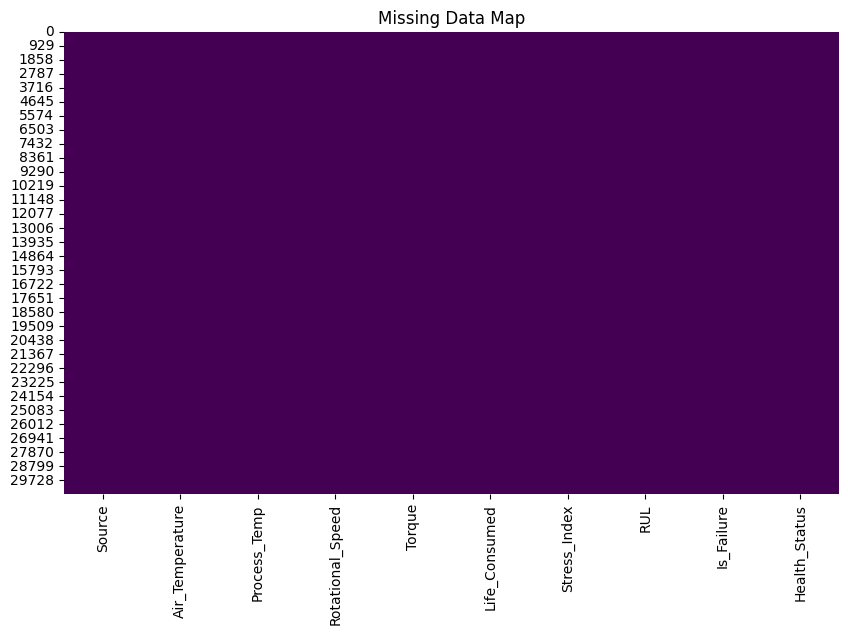

In [5]:
# check for missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Map')
plt.show()

### Feature Correlation

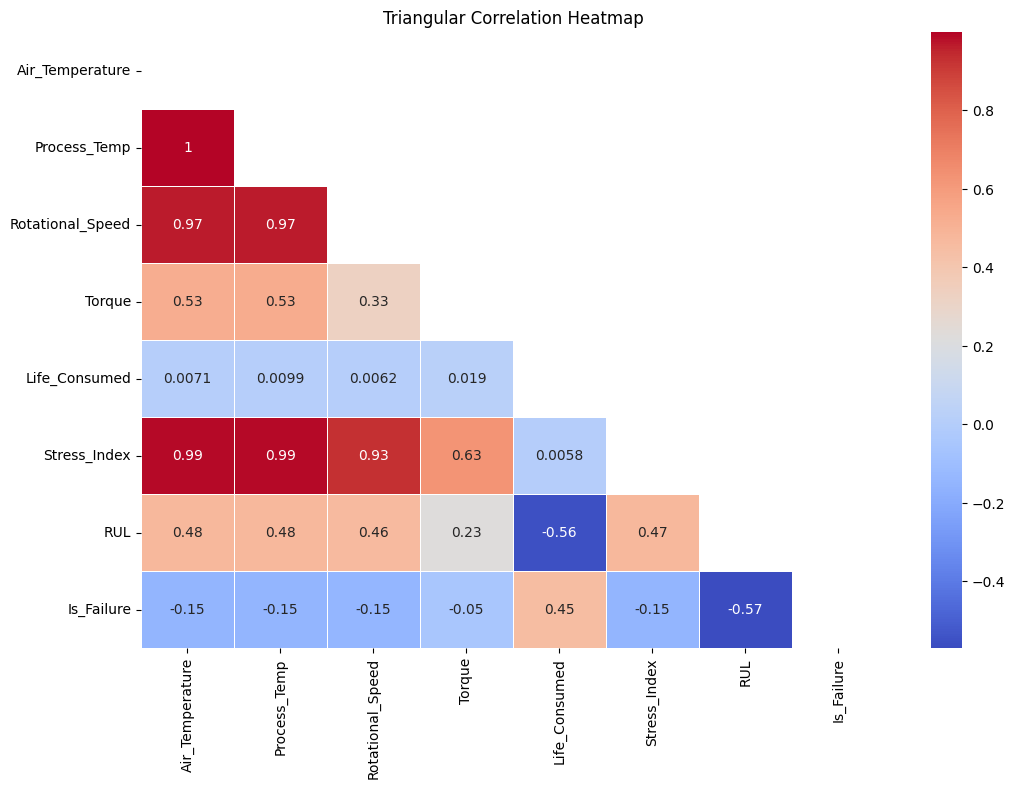

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df[numeric_cols].corr(), dtype=bool))
sns.heatmap(df[numeric_cols].corr(), mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Triangular Correlation Heatmap')
plt.show()

### Classificationn

/tmp/ipykernel_119606/487382523.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Is_Failure', data=df, palette='Set2')


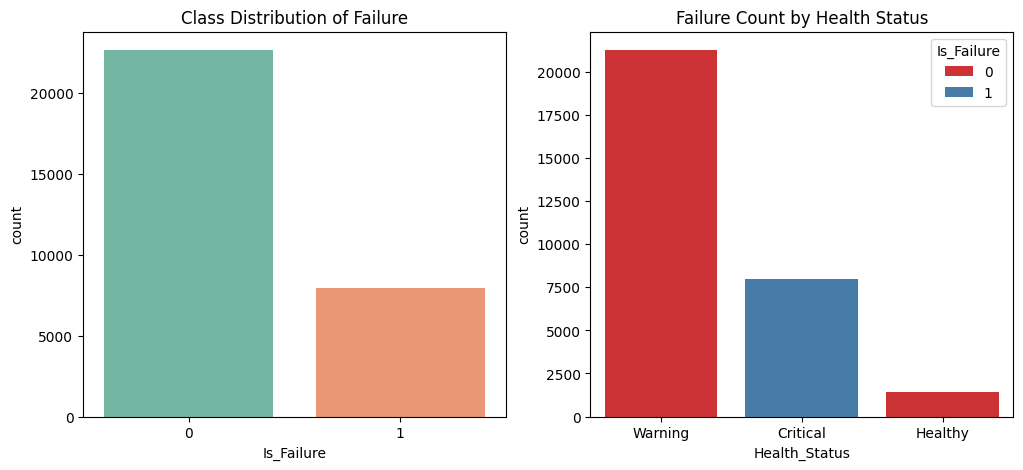

In [10]:
# Check for class imbalance
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='Is_Failure', data=df, palette='Set2')
plt.title('Class Distribution of Failure')

plt.subplot(1, 2, 2)
sns.countplot(x='Health_Status', hue='Is_Failure', data=df, palette='Set1')
plt.title('Failure Count by Health Status')
plt.show()

### Multi-Variate Relationships

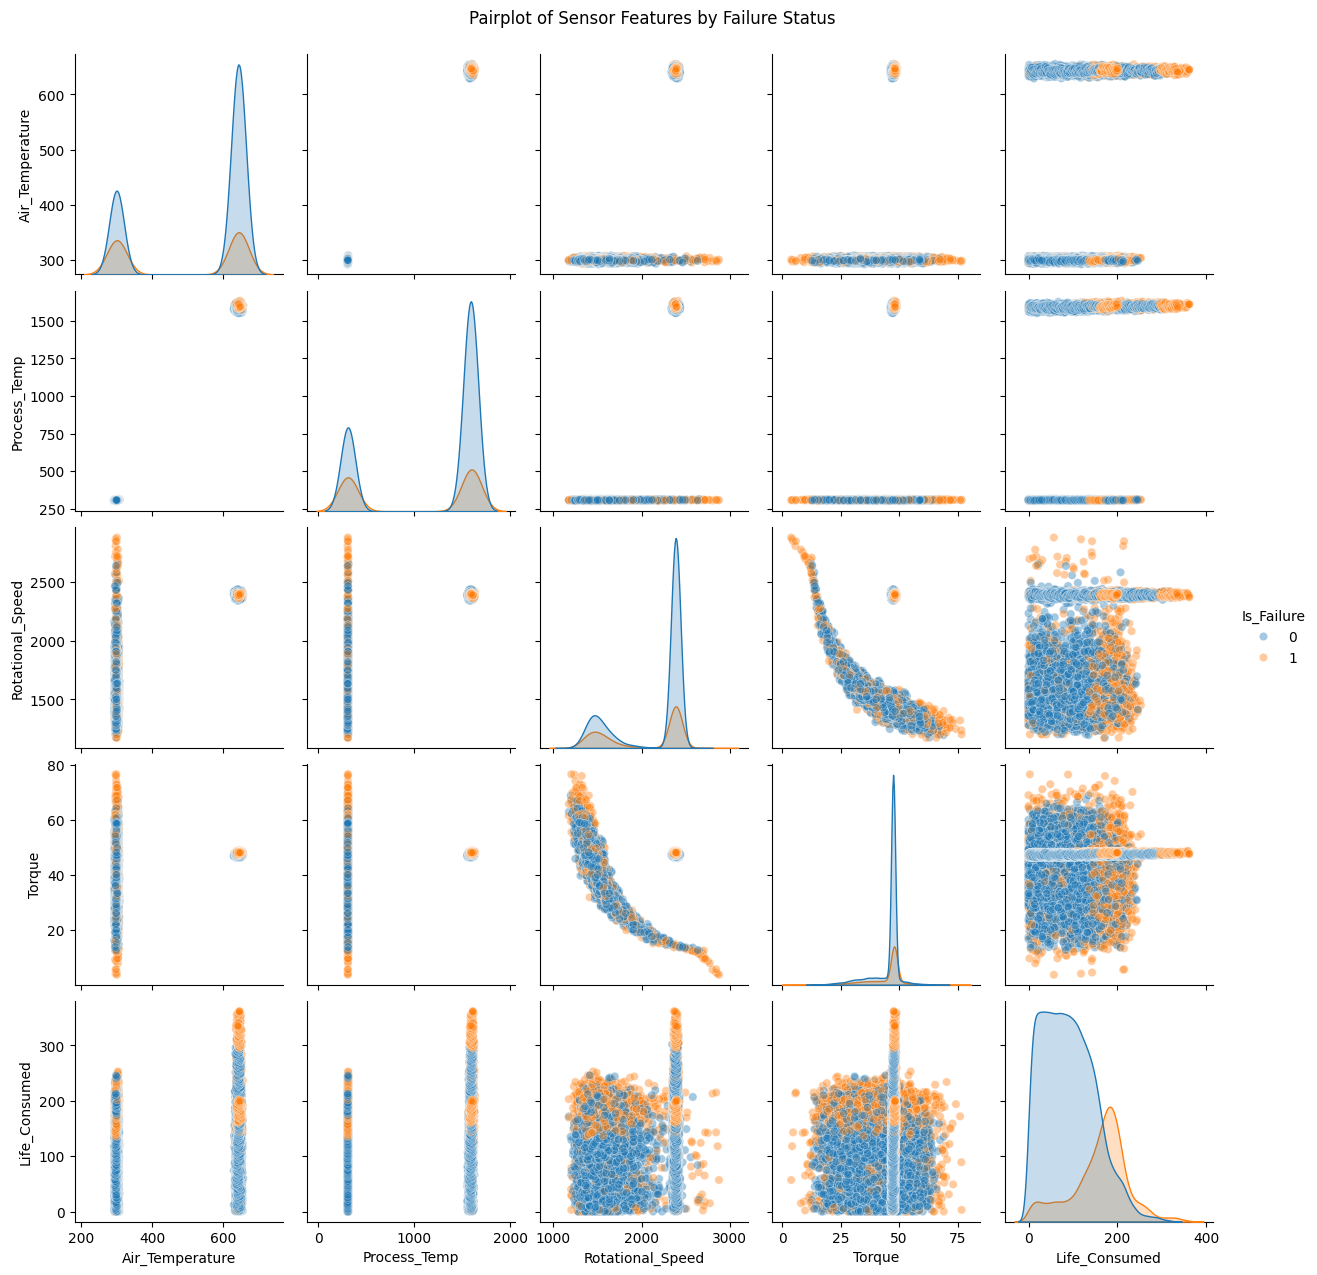

In [11]:
# Focus on the core sensor features
sensors = ['Air_Temperature', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Life_Consumed']
sns.pairplot(df, vars=sensors, hue='Is_Failure', diag_kind='kde', plot_kws={'alpha':0.4})
plt.suptitle("Pairplot of Sensor Features by Failure Status", y=1.02)
plt.show()